In [26]:
import h5py
import numpy as np    
import matplotlib.pyplot as plt
import os
import argparse
import tqdm
import matplotlib
from matplotlib.animation import FuncAnimation, PillowWriter
import scipy.ndimage.filters as filters
plt.rcParams.update({
    # "text.usetex": True,
    "font.family": 'STIXGeneral',
    "text.latex.preamble": r"\usepackage{lmodern}",
    'mathtext.fontset': 'cm'
})
fs = 15
fstick = 12


def smooth( x, window_len=61, window='hanning', axis = -1):
    return filters.convolve1d(x, np.ones(window_len)/window_len, axis=axis)

datafolder = '/travail/xgong/new_simu_highppc/output/mi25-MA40-PPC300'
# datafolder = "/travail/xgong/test_separate/output/mi25-Unmag/"
import re

match = re.search(r'mi(\d+)', datafolder)
if match:
    mi = float(match.group(1))
    print(mi)
else:
    print("no mi")

os.system('ls '+ os.path.join(datafolder, 'particles/partic*h5') + ' > ' + os.path.join(datafolder, 'filelist_prtl.txt'))
with open(os.path.join(datafolder, 'filelist_prtl.txt')) as f:
    files = f.readlines()
    for i in range(len(files)):
        files[i] = files[i].strip()
print(len(files))


os.system('ls '+ os.path.join(datafolder, 'fields/*h5') + ' > ' + os.path.join(datafolder, 'filelist_flds.txt'))
with open(os.path.join(datafolder, 'filelist_flds.txt')) as f:
    files_fld = f.readlines()
    for i in range(len(files_fld)):
        files_fld[i] = files_fld[i].strip()
# print(len(files))
%matplotlib widget

25.0
100


/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/matplotlib/colors.py:1210: RuntimeWarning: divide by zero encountered in log
  resdat -= np.log(vmin)
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/matplotlib/colors.py:1211: RuntimeWarning: divide by zero encountered in log
  resdat /= (np.log(vmax) - np.log(vmin))


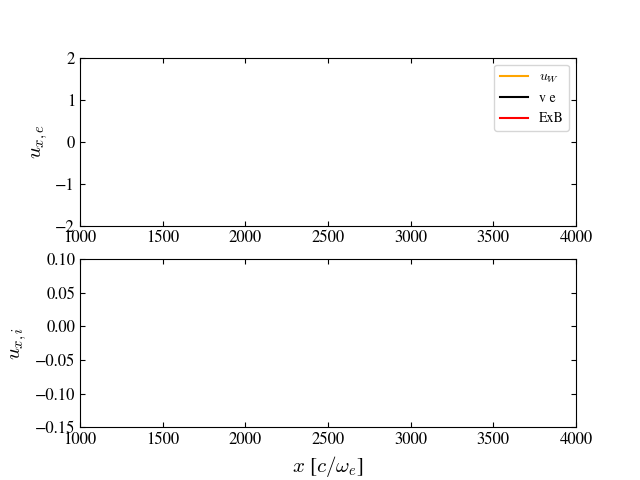

In [31]:

xmin, xmax = 0, 4e3
ymine,ymaxe = -2,2
ymini,ymaxi = -0.15,0.1
numx, numu = 800,300
fig, (ax1, ax2) = plt.subplots(2)

fill=0.6

def getuw(x,Xsh, Lsh, driftux):
    return (5./8. + 3./8. * np.tanh(2 * (x - Xsh)/Lsh)) * ( - driftux)

ax1.set_xlim(xmin, xmax)
# ax1.set_ylim(ymine,ymaxe)

jpt = ax1.hist2d([], [], bins=(np.linspace(xmin,xmax,numx),np.linspace(ymine,ymaxe,numu)), norm=matplotlib.colors.LogNorm())
ax1.plot(np.linspace(xmin,xmax,1001)/5, getuw(np.linspace(xmin,xmax,1001),xmax*fill, 150, 0.1), color = 'orange', label = r'$u_W$')
line1, = ax1.plot([],[],label='v e', color='black')
line2, = ax1.plot([],[],label='ExB', color='red')
ax1.legend()
ax1.set_xlim(1000, xmax)
# ax1.set_ylim(u11.min(),u11.max())
ax1.set_ylim(ymine,ymaxe)
ax2.set_xlim(1000, xmax)
# ax2.set_ylim(u12.min(),u12.max())
ax2.set_ylim(ymini,ymaxi)
# ax1.set_xlabel(r'x [$c / \omega_i$]')
ax1.set_ylabel(r'$u_{x, e}$',fontsize=15)
ax2.set_xlabel(r'$x$ [$c / \omega_e$]',fontsize=15)
ax2.set_ylabel(r'$u_{x, i}$',fontsize=15)
ax1.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
ax2.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)

# jpt = ax2.hist2d([], [], bins=(np.linspace(xmin,xmax,numx),np.linspace(ymini,ymaxi,numu)), norm=matplotlib.colors.LogNorm())
# ax2.plot(np.linspace(xmin,xmax,1001)/5, getuw(np.linspace(xmin,xmax,1001),xmax*fill, 500, 0.1), color = 'orange', label = r'$u_W$')
def init():
    return []
    # line1.set_data([], [])
    # line2.set_data([], [])
    # # line3.set_data([], [])
    # return line1, line2#, line3

def update(frame_idx):
    file = h5py.File(files[frame_idx])['Step0']
    file_fld = h5py.File(files_fld[frame_idx])['Step0']
    u11 = np.array(file['pU1_1'])
    u12 = np.array(file['pU1_2'])
    u21 = np.array(file['pU2_1'])
    u22 = np.array(file['pU2_2'])
    x1 = np.array(file['pX1_1'])
    x2 = np.array(file['pX1_2'])

    B3 = (np.array(file_fld['fAvgBz']))
    E2 = (np.array(file_fld['fAvgEy']))
    X_fld = np.array(file_fld['X1'])
    vEB = (E2 / B3)
    ax1.cla()
    ax2.cla()
    rese = ax1.hist2d(x1, u11, bins=(np.linspace(xmin,xmax,numx),np.linspace(u11.min(),u11.max(),numu)), norm=matplotlib.colors.LogNorm())
    resi = ax2.hist2d(x2, u12, bins=(np.linspace(xmin,xmax,numx),np.linspace(u12.min(),u12.max(),numu)), norm=matplotlib.colors.LogNorm())
    ax1.plot(np.linspace(xmin,xmax,1001), getuw(np.linspace(xmin,xmax,1001),x1.max()*fill, 500, 0.1), color = 'orange', label = r'$u_\mathrm{w}$')
    ax2.plot(np.linspace(xmin,xmax,1001), getuw(np.linspace(xmin,xmax,1001),x1.max()*fill, 500, 0.1), color = 'orange', label = r'$u_\mathrm{w}$')
    ue_prob = rese[2][np.argmax(smooth(rese[0], window_len=5,axis=-1),1)]
    ui_prob = resi[2][np.argmax(smooth(resi[0], window_len=5,axis=-1),1)]

    # line1, = ax1.plot(np.linspace(xmin,xmax,numx)[1:], ue_prob,label=r'$v_{e,maxLLH}$', color='black')
    line2, = ax1.plot(X_fld, vEB,label='ExB', color='red',lw=0.7)
    # line1, = ax2.plot(np.linspace(xmin,xmax,numx)[1:], ue_prob,label=r'$v_{e,maxLLH}$', color='pink')
    # line1, = ax2.plot(np.linspace(xmin,xmax,numx)[1:], ui_prob,label=r'$v_{i,maxLLH}$', color='black')
    line2, = ax2.plot(X_fld, vEB,label='ExB', color='red',lw=0.7)
    ax1.legend()
    ax2.legend()
    ax1.set_xlim(1000, xmax)
    # ax1.set_ylim(u11.min(),u11.max())
    ax1.set_ylim(ymine,ymaxe)
    ax2.set_xlim(1000, xmax)
    # ax2.set_ylim(u12.min(),u12.max())
    ax2.set_ylim(ymini,ymaxi)
    # ax1.set_xlabel(r'x [$c / \omega_i$]')
    ax1.set_ylabel(r'$u_{x, e}$',fontsize=15)
    ax2.set_xlabel(r'$x$ [$c / \omega_e$]',fontsize=15)
    ax2.set_ylabel(r'$u_{x, i}$',fontsize=15)
    ax1.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
    ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
    ax2.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
    ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
    # ax2.set_ylim(u12.min(),u12.max())
    return []


ani = FuncAnimation(fig, update, frames=range(0,len(files),1), init_func=init, blit=True)
# update(-1)
# ani.save("./plots/MA400Prtl.gif", writer=PillowWriter(fps=8), dpi=300)
# plt.show()


<KeysViewHDF5 ['Step', 'Time', 'pIDX_1', 'pIDX_2', 'pU1_1', 'pU1_2', 'pU2_1', 'pU2_2', 'pU3_1', 'pU3_2', 'pW_1', 'pW_2', 'pX1_1', 'pX1_2']>


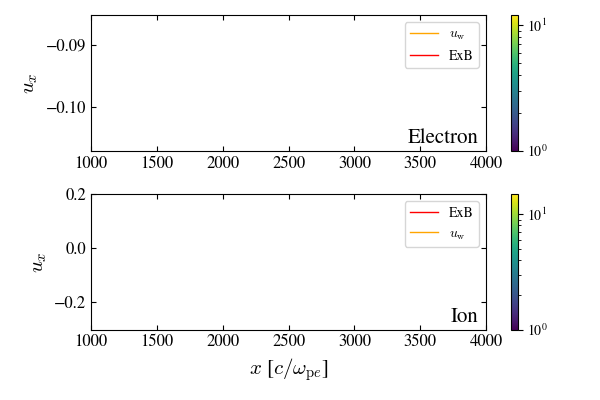

In [2]:
x = -1
import matplotlib

def getuw(x,Xsh, Lsh, driftux):
    return (5./8. + 3./8. * np.tanh(2 * (x - Xsh)/Lsh)) * ( - driftux)
file = h5py.File(files[x], 'r')['Step0']
file_fld =h5py.File( files_fld[x], 'r')['Step0']
B3 = (np.array(file_fld['fAvgBz']))
E2 = (np.array(file_fld['fAvgEy']))
X_fld = np.array(file_fld['X1'])
vEB = (E2 / B3)


print(file.keys())
u11 = np.array(file['pU1_1'])
u12 = np.array(file['pU1_2'])
u21 = np.array(file['pU2_1'])
u22 = np.array(file['pU2_2'])
u31 = np.array(file['pU3_1'])
u32 = np.array(file['pU3_2'])
x1 = np.array(file['pX1_1'])
x2 = np.array(file['pX1_2'])

# xmax = x2.max()
xmin,xmax = 0,x1.max()
fill=0.6
numx, numu = 800,300

fig,(ax1, ax2) = plt.subplots(2,figsize = (6,4))
res = ax1.hist2d(x1, u11, bins=(np.linspace(xmin,xmax,numx),np.linspace(u11.min(),u11.max(),numu)), norm=matplotlib.colors.LogNorm())
ax1.set_ylabel(r'$u_x$', fontsize= 15)
# ax1.set_xlabel(r'$x$ [$c / \omega_{\mathrm{p}e}$]', fontsize= 15)
# ax1.plot([0,xmax],[-0.1,-0.1], color = 'red', lw=0.5)
fig.colorbar(ax = ax1, mappable=res[3])
# uprob = (res[2][1:] * res[0]).sum(1)/ res[0].sum(1)
uprob = (res[2][np.argmax(res[0],1)])
# plt.plot(np.linspace(xmin,xmax,numx)[1:], uprob, color = 'black')
ax1.plot(np.linspace(xmin,xmax,numx), getuw(np.linspace(xmin,xmax,numx),x1.max()*fill, 150, 0.1), color = 'orange', lw = 1,label = r'$u_\mathrm{w}$')
ax1.plot(X_fld, vEB, color='red', label='ExB',lw = 1)
# ax1.grid()
ax1.legend()
ax1.text(
    0.98, 0.02,            
    "Electron",               
    transform=ax1.transAxes,
    ha='right', va='bottom',
    fontsize=  15
)

# plt.ylim(-3,3e3)


res = ax2.hist2d(x2, u12, bins=(np.linspace(xmin,xmax,numx),np.linspace(u12.min(),u12.max(),numu)), norm=matplotlib.colors.LogNorm())

ax2.set_ylabel(r'$u_x$', fontsize= 15)
ax2.set_xlabel(r'$x$ [$c / \omega_{\mathrm{p}e}$]', fontsize= 15)
# ax2.plot([xmin,xmax],[-0.1,-0.1], color = 'red', lw=0.5)
ax2.plot(X_fld, vEB, color='red', label='ExB',lw = 1)
ax2.plot(np.linspace(xmin,xmax,numx), getuw(np.linspace(xmin,xmax,numx),x1.max()*fill, 150, 0.1), color = 'orange',lw = 1, label = r'$u_\mathrm{w}$')
ax2.text(
    0.98, 0.02,              
    "Ion",               
    transform=ax2.transAxes,
    ha='right', va='bottom',
    fontsize=  15
)

fig.colorbar(ax = ax2, mappable=res[3])
ax2.legend()
ax1.set_xlim(1e3,4e3)
ax2.set_xlim(1e3,4e3)
ax2.set_ylim(-0.3,0.2)

plt.tight_layout()
ax1.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
ax2.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
# plt.savefig("./plots/IonPhaseMA400.png", dpi = 500, bbox_size = 'tight')
# plt.savefig("./plots/MA40Prtl.png", dpi = 500, bbox_size = 'tight')


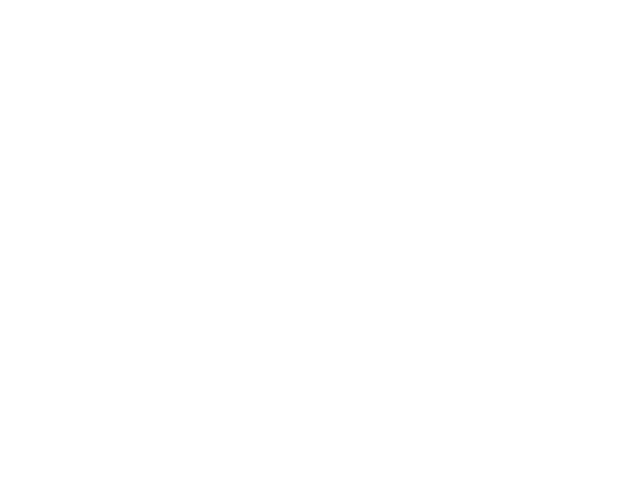

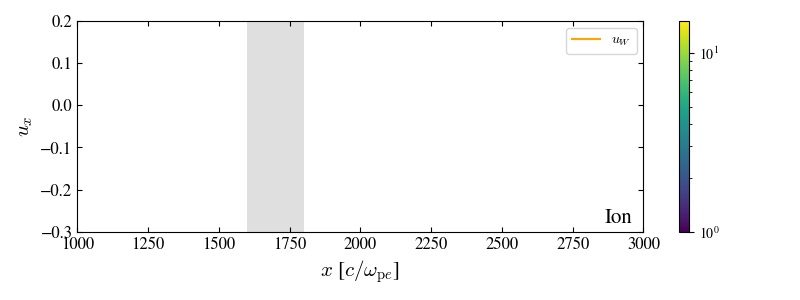

In [3]:
plt.cla()
plt.figure()
fig,ax2 = plt.subplots(figsize = (8,3))
res = ax2.hist2d(x2, u12, bins=(np.linspace(xmin,xmax,numx),np.linspace(u12.min(),u12.max(),numu)), norm=matplotlib.colors.LogNorm())

ax2.set_ylabel(r'$u_x$', fontsize= 15)
ax2.set_xlabel(r'$x$ [$c / \omega_{\mathrm{p}e}$]', fontsize= 15)
# ax2.plot([xmin,xmax],[-0.1,-0.1], color = 'red', lw=0.5)
# ax2.plot(X_fld, vEB, color='red', label='ExB')
ax2.plot(np.linspace(xmin,xmax,numx), getuw(np.linspace(xmin,xmax,numx),x1.max()*fill, 500, 0.1), color = 'orange', label = r'$u_W$')
ax2.text(
    0.98, 0.02,              
    "Ion",               
    transform=ax2.transAxes,
    ha='right', va='bottom',
    fontsize=  15
)

fig.colorbar(ax = ax2, mappable=res[3])
ax2.legend()
ax1.set_xlim(1e3,3e3)
ax2.set_xlim(1e3,3e3)
ax2.set_ylim(-0.3,0.2)
from matplotlib.patches import Rectangle

rect = Rectangle(
    (1600, -1),      # (x, y) bottom-left corner
    200, 2,          # width, height
    linewidth=0,
    facecolor='gray',
    alpha=0.25     # transparency
)
ax2.add_patch(rect)

ax2.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
plt.tight_layout()


# plt.savefig("./plots/UnmagPrtl.png", dpi = 500, bbox_size='tight')


# Ux - Uy

0.7732125584212477


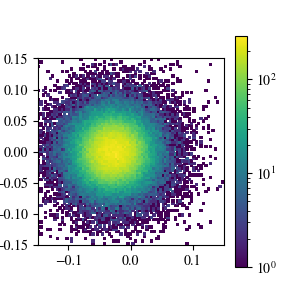

In [38]:
plt.figure(figsize=(3,3))
x = -1
file = h5py.File(files[x], 'r')['Step0']
u11 = np.array(file['pU1_1'])
u12 = np.array(file['pU1_2'])
u21 = np.array(file['pU2_1'])
u22 = np.array(file['pU2_2'])
u31 = np.array(file['pU3_1'])
u32 = np.array(file['pU3_2'])
x1 = np.array(file['pX1_1'])
x2 = np.array(file['pX1_2'])
# x2 = np.array(file['pX1_2'])
idx = np.where((x2 > 300) & (x2 < 500))
plt.hist2d(u12[idx], u32[idx], bins = [np.linspace(-0.15,0.15,80),np.linspace(-0.15,0.15,80)], norm=matplotlib.colors.LogNorm())
fig = plt.gca()
fig.set_aspect(1)
plt.colorbar()
npart = idx[0].shape[0]
nbeam = np.where(u12[idx] > -0.05)[0].shape[0]
print(nbeam / npart)

# plt.figure(figsize=(3,3))
# idx = np.where((x2 > 1000) & (x2 < 1400))
# plt.hist2d(u32[idx],u12[idx], bins = [np.linspace(-0.25,0.25,100),np.linspace(-0.3,0.2,100)], norm=matplotlib.colors.LogNorm())
# fig = plt.gca()
# plt.ylabel(r"$u_{i,x}$", fontsize=15)
# plt.xlabel(r"$u_{i,z}$", fontsize=15)
# fig.set_aspect(1)
# plt.tight_layout()
# plt.colorbar(shrink=0.8)

# plt.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
# plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
# # plt.savefig("./plots/beam.png", dpi=500, bbox_size='tight')

100%|██████████| 200/200 [00:00<00:00, 863.34it/s]


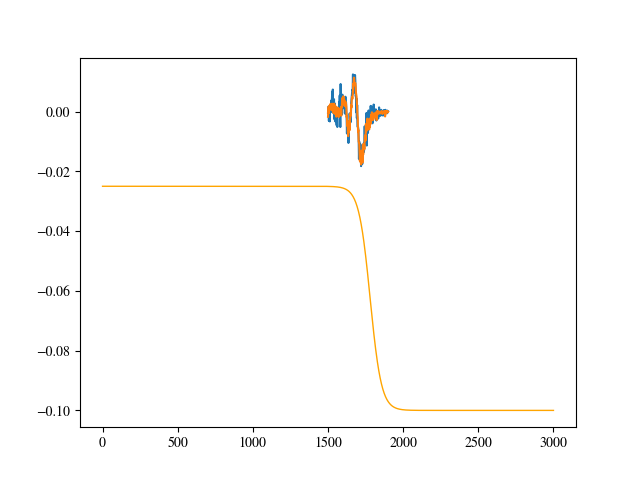

In [32]:
x = -2
file = h5py.File(files[x], 'r')['Step0']
u11 = np.array(file['pU1_1'])
u12 = np.array(file['pU1_2'])
u21 = np.array(file['pU2_1'])
u22 = np.array(file['pU2_2'])
u31 = np.array(file['pU3_1'])
u32 = np.array(file['pU3_2'])
x1 = np.array(file['pX1_1'])
x2 = np.array(file['pX1_2'])
# x2 = np.array(file['pX1_2'])
# idx = np.where((x2 > 1500) & (x2 < 1900))[0]
bins = np.linspace(1500,1900, 201)
u1prof = np.zeros_like(bins)
for i in tqdm.trange(bins.shape[0]-1):
    idx_in_bin = np.where((x1 > bins[i]) & (x1 < bins[i+1]))[0]
    u1prof[i] = np.mean(u21[idx_in_bin])

u2prof = np.zeros_like(bins)
for i in tqdm.trange(bins.shape[0]-1):
    idx_in_bin = np.where((x2 > bins[i]) & (x2 < bins[i+1]))[0]
    u2prof[i] = np.mean(u22[idx_in_bin])

plt.figure()
plt.plot(bins, u1prof)
plt.plot(bins, u2prof)


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:00<00:00, 819.02it/s]


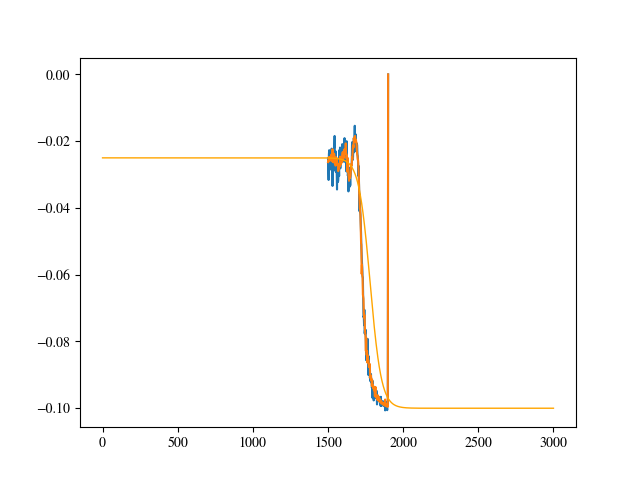

In [34]:
x = -2
file = h5py.File(files[x], 'r')['Step0']
u11 = np.array(file['pU1_1'])
u12 = np.array(file['pU1_2'])
u21 = np.array(file['pU2_1'])
u22 = np.array(file['pU2_2'])
u31 = np.array(file['pU3_1'])
u32 = np.array(file['pU3_2'])
x1 = np.array(file['pX1_1'])
x2 = np.array(file['pX1_2'])
# x2 = np.array(file['pX1_2'])
# idx = np.where((x2 > 1500) & (x2 < 1900))[0]
bins = np.linspace(1500,1900, 201)
u1prof = np.zeros_like(bins)
for i in tqdm.trange(bins.shape[0]-1):
    idx_in_bin = np.where((x1 > bins[i]) & (x1 < bins[i+1]))[0]
    u1prof[i] = np.mean(u11[idx_in_bin])

u2prof = np.zeros_like(bins)
for i in tqdm.trange(bins.shape[0]-1):
    idx_in_bin = np.where((x2 > bins[i]) & (x2 < bins[i+1]))[0]
    u2prof[i] = np.mean(u12[idx_in_bin])

plt.figure()
plt.plot(bins, u1prof)
plt.plot(bins, u2prof)
plt.plot(np.linspace(0,3000,1000), getuw(np.linspace(0,3000,1000),x1.max()*0.6,150, 0.1), color = 'orange',lw = 1, label = r'$u_\mathrm{w}$')


In [26]:
xx = np.mean((u12[idx]-np.mean(u12[idx]))**2)
yy=  np.mean(u32[idx]**2)
xy = np.mean((u12[idx]-np.mean(u12[idx]))*u32[idx])
eta = np.sqrt((xx - yy)**2 + xy**2) / (xx+yy)/2
eta

0.0023168943053868685

# Spectra


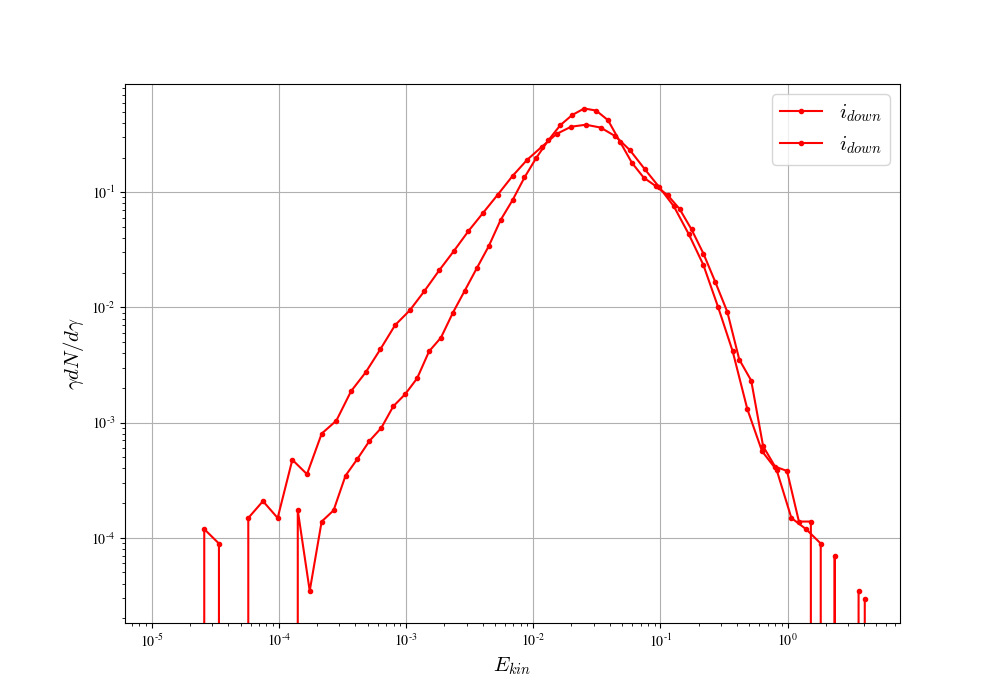

In [42]:
# %matplotlib inline

x = -1
file = h5py.File(files[x], 'r')['Step0']
mi=25

def AngDist(x1, x2, spec, file):
    if spec == 1:
        m = 1.
    else:
        m = mi
    spec = str(spec)
    x = np.array(file['pX1_' + spec])
    u1 = np.array(file['pU1_'+ spec])
    u2 = np.array(file['pU2_'+ spec])
    u3 = np.array(file['pU3_'+ spec])

    targidx = np.argwhere((x1< x) & (x < x2)).flatten()
    u1 = u1[targidx]
    u2 = u2[targidx]
    u3 = u3[targidx]

    v1 = u1 / np.sqrt(1 + u1**2 + u2**2 + u3**2)
    v2 = u2 / np.sqrt(1 + u1**2 + u2**2 + u3**2)
    v3 = u3 / np.sqrt(1 + u1**2 + u2**2 + u3**2)

    V1 = v1.mean()
    V2 = v2.mean()
    V3 = v3.mean()
    V = np.array([V1, V2, V3])
    V2_mag2 = np.dot(V, V)
    gamma_V = 1 / np.sqrt(1 - V2_mag2)

    v_particle = np.stack([v1, v2, v3], axis=1)

    dot = np.sum(v_particle * V, axis=1)
    factor = 1 / (1 - dot)
    v_rel = (v_particle - V) * factor[:, None]

    v_mod = np.linalg.norm(v_rel, axis=1) #* np.sqrt(m)

    gm = 1 / np.sqrt(1 - v_mod**2)

    v_mod = (gm-1) * m

    if v_mod.shape[0] == 0:
        return (np.array([]),np.array([]))
    bins = np.logspace(np.log10(v_mod.min() + 1e-8), np.log10(v_mod.max()), 50)
    img = np.histogram(v_mod, bins=bins, density=True)
    # plt.close()
    
    return (img[1][:-1], img[0][:])


def func(x, ynorm, xnorm,sig):
    return ynorm * np.exp(-((x - xnorm) / sig)**2)



from scipy.optimize import curve_fit


plt.figure(figsize=(10,7))

def integrate(x,y):
    return ((y[1:]+ y[:-1])/2*(x[1:] - x[:-1])).sum()


def plotvdis(xlow, xhigh, spec, file, label, color):
    xu,yu = AngDist(xlow, xhigh,spec,file)
    plt.plot(xu,yu*xu, label=label, marker = '.', color = color)
    return integrate(xu,xu*yu) /integrate(xu,yu) #xu[np.where(yu*xu == (yu*xu).max())]

# ted = plotvdis(300,500,1,file,r'$e_{down}$', 'blue')
tid = plotvdis(300,500,2,file, r'$i_{down}$', 'red')
tid = plotvdis(1500,1700,2,file, r'$i_{down}$', 'red')

plt.legend(fontsize = 15)
plt.xscale('log')
plt.yscale('log')

plt.ylabel(r'$\gamma dN/d\gamma$',fontsize = 15)
plt.xlabel(r'$E_{kin}$',fontsize = 15)

plt.grid()
# plt.savefig('mbdist_strongscatt.png', dpi=300)


# Plot Spectra Evolution Movie

/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:28: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:29: RuntimeWarning: Mean of empty slice.


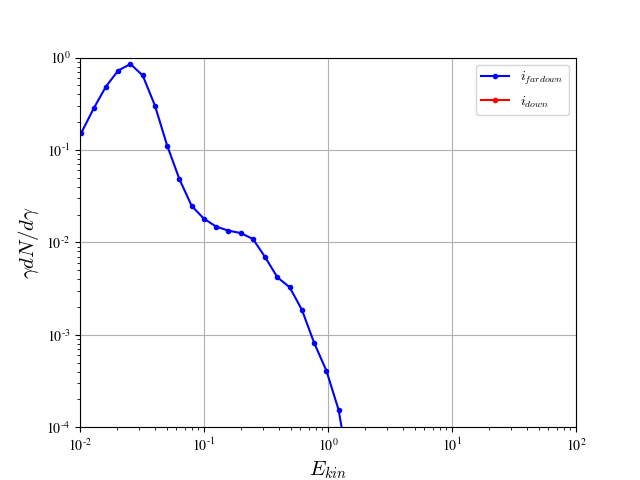

/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:28: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:29: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:28: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:29: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:28: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3

In [5]:
%matplotlib widget
fig,ax = plt.subplots()
line1, = ax.plot([],[],label=r'$i_{fardown}$',  marker = '.',color='blue')
line2, = ax.plot([],[],label=r'$i_{down}$',  marker = '.',color='red')
def init():
    line1.set_data([],[])
    line2.set_data([],[])
    return line1,line2

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-2,1e2)
ax.set_ylim(1e-4, 1e0)
ax.set_ylabel(r'$\gamma dN/d\gamma$',fontsize = 15)
ax.set_xlabel(r'$E_{kin}$',fontsize = 15)
ax.grid()
ax.legend()

def update(frame_idx):
    file = h5py.File(files[frame_idx], 'r')['Step0']
    # ax.cla()
    def plotvdis(xlow, xhigh, spec, file, label, color):
        xu,yu = AngDist(xlow, xhigh,spec,file)
        # ax.plot(xu,yu*xu, label=label, marker = '.', color = color)
        return (xu, yu*xu)
    mr = 25
    line1.set_data(*plotvdis(1000,1400,2,file,r'$i_{fardown}$', 'blue'))
    # line2.set_data(*plotvdis(11000,13000,2,file, r'$i_{down}$', 'red'))


    return (line1,line2)

ani = FuncAnimation(fig, update, frames=range(0,len(files),1), init_func=init, blit=True)
ani.save("./plots/spec_ma40_1836.gif", writer=PillowWriter(fps=5))


In [12]:
X = np.linspace(2000,4900,101)
Te = np.zeros_like(X)
Ti = np.zeros_like(X)


for i in tqdm.trange(X.shape[0]-1):
    Te[i] = plotvdis(X[i],X[i+1] , 1, file, None, None)
    Ti[i] = plotvdis(X[i],X[i+1] , 2, file, None, None)



100%|██████████| 100/100 [00:08<00:00, 11.57it/s]


In [34]:
plt.figure()
plt.plot(X[:-1],(Te/Ti)[:-1], label='Te/Ti')
# plt.plot(X,Ti)
plt.xlabel('x')
plt.ylabel('P [P0]')
plt.title(r'$M_A$=40, M=100, $m_i$=25, Broad transition ($L_{sh}\sim 100 c/\omega_i$)')
plt.xlim(2000,4900)

plt.plot(np.linspace(0,5000,1001), getuw(np.linspace(0,5000,1001),5000*0.7, 500, 0.1), color = 'orange', label=r"$u_{weib}$")
plt.legend()


NameError: name 'X' is not defined

<Figure size 432x288 with 0 Axes>

v -> v + qFv dv  (gyro)
v -> rotation

x -> ( v_prev + v ) dt
 v_prev -> qF + rotation

Const nu_scatt -> fast particles explore more space -> 